# Controlled Optimization of the Baseline

The reference notebook is preserved as Baseline v1. This notebook performs EDA and leakage-safe experiments without changing the reference preprocessing silently.

In [1]:
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
TARGET = "Target"
DATA_PATH = "dataset (1).csv"
CLASS_NAMES = ["Dropout", "Enrolled", "Graduate"]
np.random.seed(RANDOM_STATE)

## 1. Load data

The dataset path and target name match the reference notebook.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Target: {TARGET}")
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df.head())

Dataset shape: (4424, 35)
Target: Target
Duplicate rows: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Dataset overview and data quality

Check samples, data types, missing values, duplicates, cardinality, and target balance before modeling.

In [3]:
overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
    }
)
display(overview)
display(df[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame("count"))

,dtype,missing,missing_pct,unique
Marital status,int64,0,0.0,6
Application mode,int64,0,0.0,18
Application order,int64,0,0.0,8
Course,int64,0,0.0,17
Daytime/evening attendance,int64,0,0.0,2
Previous qualification,int64,0,0.0,17
Nacionality,int64,0,0.0,21
Mother's qualification,int64,0,0.0,29
Father's qualification,int64,0,0.0,34
Mother's occupation,int64,0,0.0,32


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


## 3. Target analysis

Enrolled is monitored explicitly because it is the weakest baseline class.

,count,percentage
Target,,
Dropout,1421,32.12
Enrolled,794,17.95
Graduate,2209,49.93


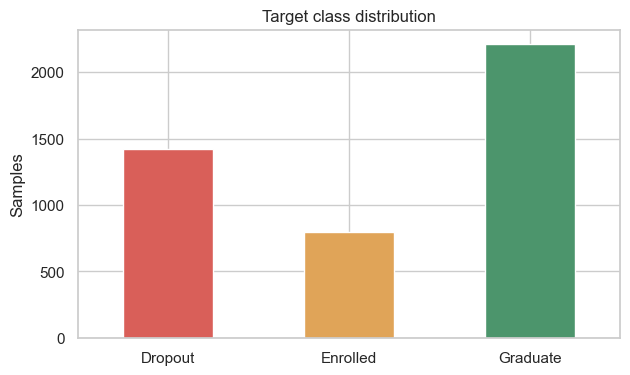

In [4]:
target_counts = df[TARGET].value_counts().reindex(CLASS_NAMES)
target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": (target_counts / len(df) * 100).round(2),
    }
)
display(target_summary)
ax = target_summary["count"].plot(
    kind="bar", color=["#d95f59", "#e0a458", "#4c956c"], figsize=(7, 4)
)
ax.set_title("Target class distribution")
ax.set_xlabel("")
ax.set_ylabel("Samples")
plt.xticks(rotation=0)
plt.show()

## 4. Feature groups from the baseline

These lists are copied from the reference notebook. Numeric-coded categorical columns remain explicit.

In [5]:
numerical_cols = [
    "Age at enrollment",
    "Application order",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
categorical_cols = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]
assert set(numerical_cols + categorical_cols + [TARGET]) == set(df.columns)
print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 17
Categorical features: 17


## 5. Numerical feature EDA

Inspect distributions, mean, median, spread, skewness, and IQR outliers. Outliers are not removed automatically.

,mean,median,std,min,max,skewness
Age at enrollment,23.265,20.000,7.588,17.00,70.000,2.055
Application order,1.728,1.000,1.314,0.00,9.000,1.881
Curricular units 1st sem (credited),0.710,0.000,2.361,0.00,20.000,4.169
Curricular units 1st sem (enrolled),6.271,6.000,2.480,0.00,26.000,1.619
Curricular units 1st sem (evaluations),8.299,8.000,4.179,0.00,45.000,0.977
Curricular units 1st sem (approved),4.707,5.000,3.094,0.00,26.000,0.766
Curricular units 1st sem (grade),10.641,12.286,4.844,0.00,18.875,-1.568
Curricular units 1st sem (without evaluations),0.138,0.000,0.691,0.00,12.000,8.207
Curricular units 2nd sem (credited),0.542,0.000,1.919,0.00,19.000,4.635
Curricular units 2nd sem (enrolled),6.232,6.000,2.196,0.00,23.000,0.788


,iqr_outlier_count
Curricular units 2nd sem (grade),877
Curricular units 1st sem (grade),726
Curricular units 1st sem (credited),577
Application order,541
Curricular units 2nd sem (credited),530
Age at enrollment,441
Curricular units 1st sem (enrolled),424
Curricular units 2nd sem (enrolled),369
Curricular units 1st sem (without evaluations),294
Curricular units 2nd sem (without evaluations),282


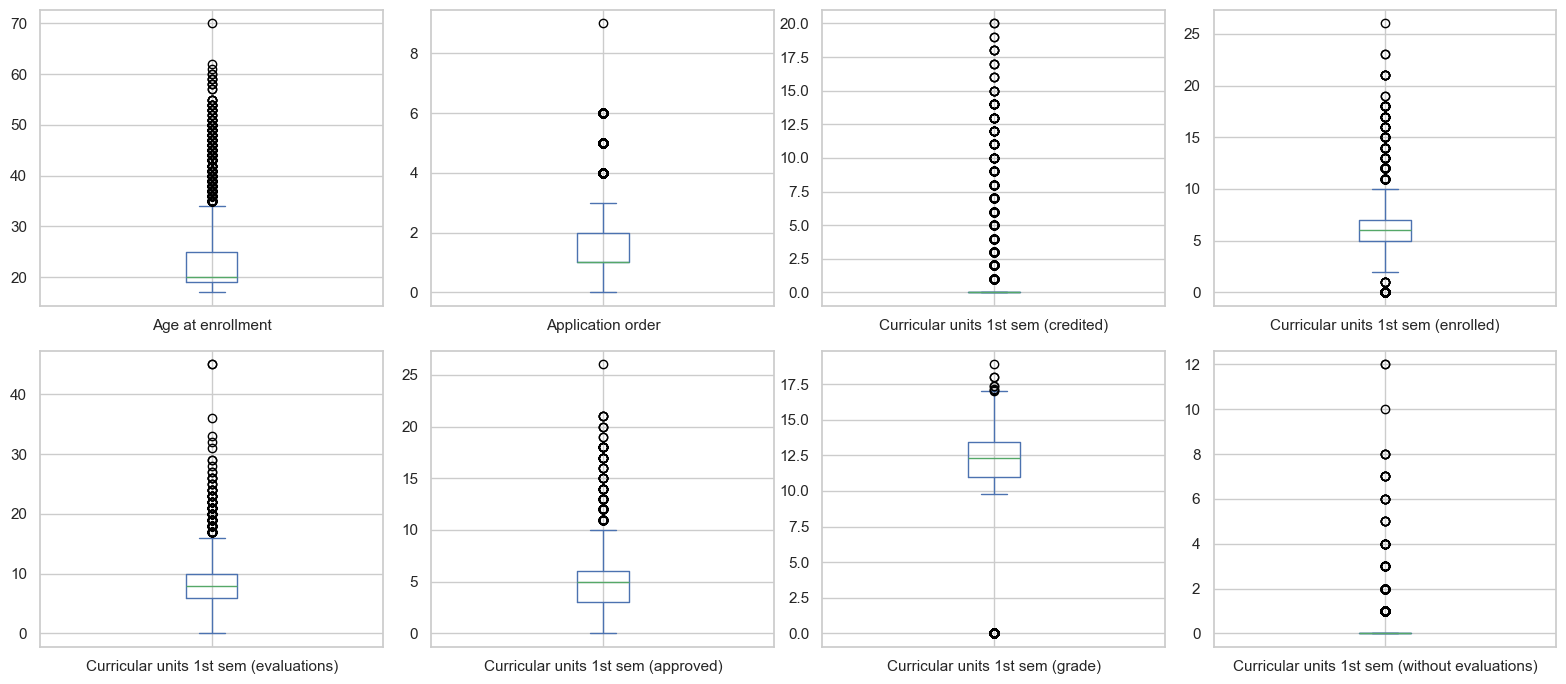

In [6]:
numeric_summary = df[numerical_cols].describe().T
numeric_summary["median"] = df[numerical_cols].median()
numeric_summary["skewness"] = df[numerical_cols].skew()
display(numeric_summary[["mean", "median", "std", "min", "max", "skewness"]].round(3))
q1 = df[numerical_cols].quantile(0.25)
q3 = df[numerical_cols].quantile(0.75)
iqr = q3 - q1
outlier_counts = (
    (df[numerical_cols] < (q1 - 1.5 * iqr)) | (df[numerical_cols] > (q3 + 1.5 * iqr))
).sum()
display(
    outlier_counts.sort_values(ascending=False).rename("iqr_outlier_count").to_frame()
)
df[numerical_cols[:8]].plot(
    kind="box", subplots=True, layout=(2, 4), figsize=(16, 7), sharey=False
)
plt.tight_layout()
plt.show()

## 6. Categorical feature EDA

Scan frequency distributions and rare categories.

In [7]:
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    rare = int((counts < max(5, 0.01 * len(df))).sum())
    print(f"{col}: {df[col].nunique()} categories; rare categories: {rare}")

Marital status: 6 categories; rare categories: 3
Application mode: 18 categories; rare categories: 9
Course: 17 categories; rare categories: 1
Daytime/evening attendance: 2 categories; rare categories: 0
Previous qualification: 17 categories; rare categories: 12
Nacionality: 21 categories; rare categories: 20
Mother's qualification: 29 categories; rare categories: 21
Father's qualification: 34 categories; rare categories: 27
Mother's occupation: 32 categories; rare categories: 22
Father's occupation: 46 categories; rare categories: 34
Displaced: 2 categories; rare categories: 0
Educational special needs: 2 categories; rare categories: 0
Debtor: 2 categories; rare categories: 0
Tuition fees up to date: 2 categories; rare categories: 0
Gender: 2 categories; rare categories: 0
Scholarship holder: 2 categories; rare categories: 0
International: 2 categories; rare categories: 0


## 7. Correlation and feature relationships

Correlation and class-normalized relationships are screening signals, not causal evidence.

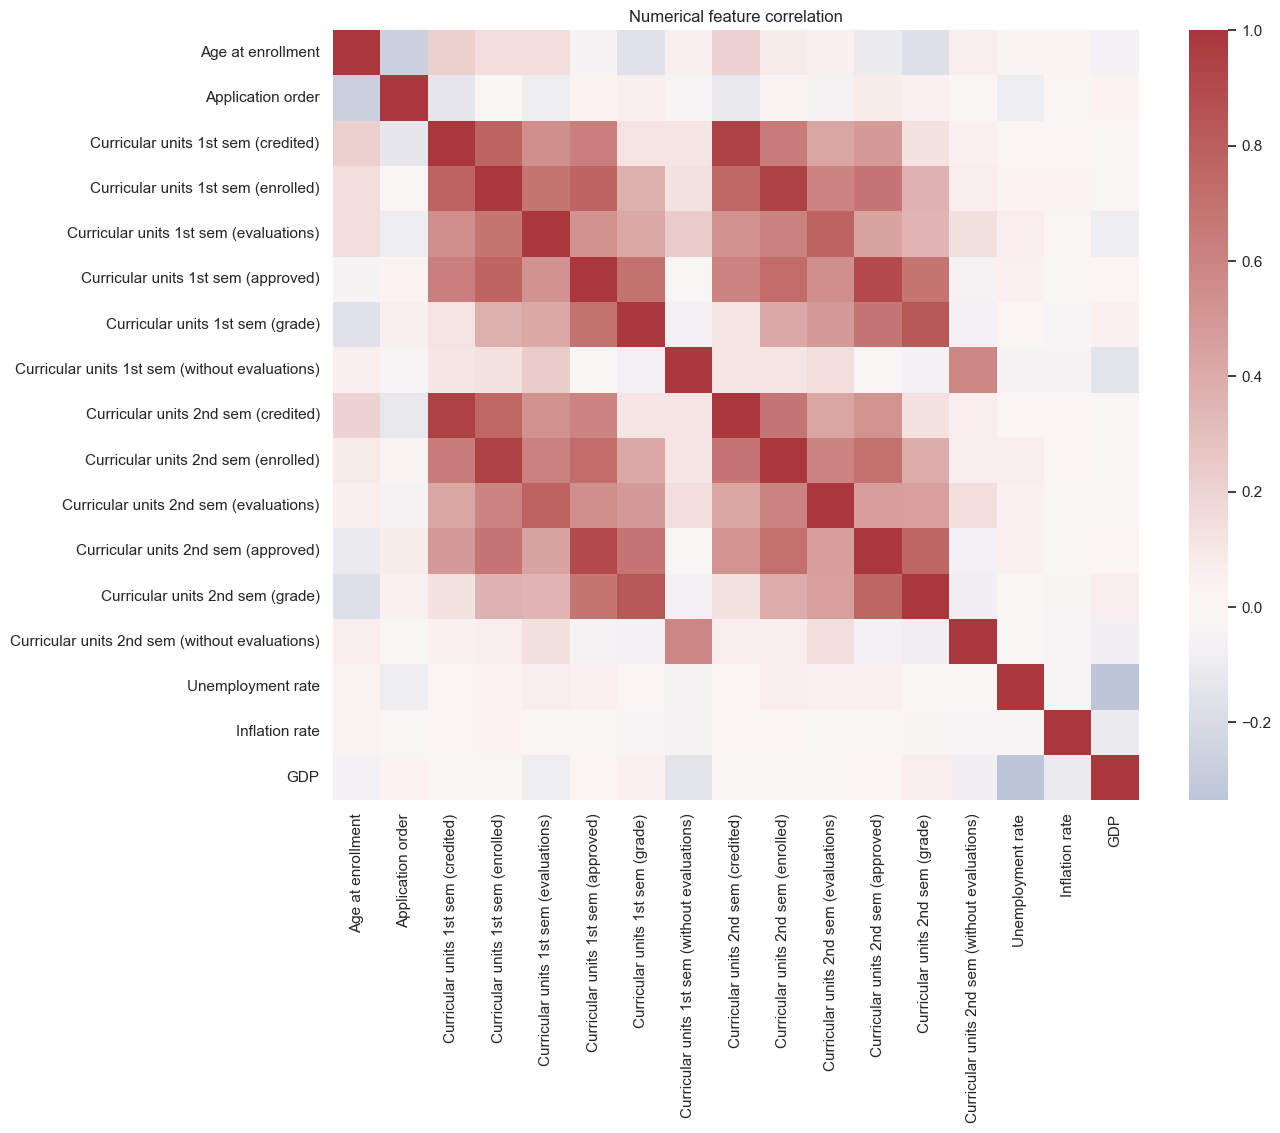

Target,Dropout,Enrolled,Graduate
Age at enrollment,23.00,20.00,19.00
Application order,1.00,1.00,1.00
Curricular units 1st sem (credited),0.00,0.00,0.00
Curricular units 1st sem (enrolled),6.00,6.00,6.00
Curricular units 1st sem (evaluations),8.00,9.00,8.00
Curricular units 1st sem (approved),2.00,5.00,6.00
Curricular units 1st sem (grade),10.93,12.00,13.00
Curricular units 1st sem (without evaluations),0.00,0.00,0.00
Curricular units 2nd sem (credited),0.00,0.00,0.00
Curricular units 2nd sem (enrolled),6.00,6.00,6.00


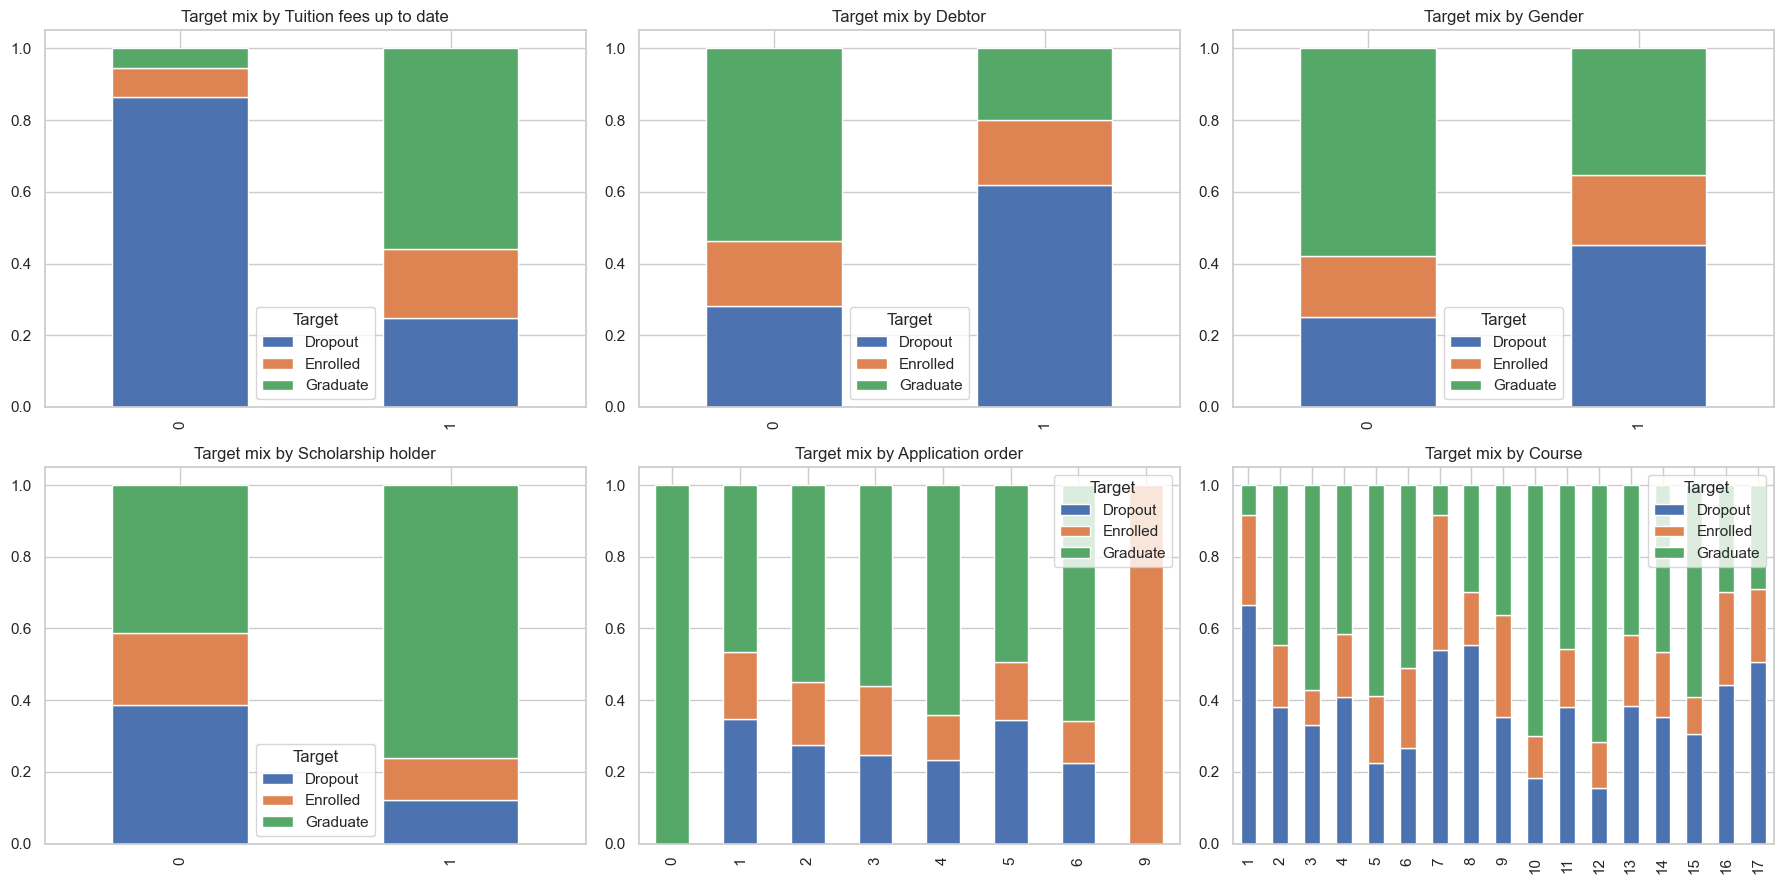

In [8]:
plt.figure(figsize=(13, 10))
sns.heatmap(df[numerical_cols].corr(), cmap="vlag", center=0, annot=False)
plt.title("Numerical feature correlation")
plt.show()
display(df.groupby(TARGET)[numerical_cols].median().T.round(2))
relationship_cols = [
    "Tuition fees up to date",
    "Debtor",
    "Gender",
    "Scholarship holder",
    "Application order",
    "Course",
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for axis, col in zip(axes.ravel(), relationship_cols):
    table = pd.crosstab(df[col], df[TARGET], normalize="index").reindex(
        columns=CLASS_NAMES, fill_value=0
    )
    table.plot(kind="bar", stacked=True, ax=axis)
    axis.set_title(f"Target mix by {col}")
    axis.set_xlabel("")
plt.tight_layout()
plt.show()

## 8. Leakage-safe split

The reference uses LabelEncoder, stratified 80/20 split, and random state 42. Validation is created from training only.

In [9]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[TARGET])
X = df.drop(columns=[TARGET])
assert list(label_encoder.classes_) == CLASS_NAMES
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)
print(f"Train: {len(X_train)}, validation: {len(X_valid)}, test: {len(X_test)}")

Train: 3539, validation: 708, test: 885


## 9. Evaluation helpers

Experiments are ranked using validation Macro-F1, Enrolled F1, and Accuracy. The test set is excluded from selection.

In [10]:
def evaluate_predictions(y_true, y_pred, experiment_id, model_name, split="validation"):
    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )
    return {
        "Experiment": experiment_id,
        "Model": model_name,
        "Split": split,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Dropout F1": report["Dropout"]["f1-score"],
        "Enrolled F1": report["Enrolled"]["f1-score"],
        "Graduate F1": report["Graduate"]["f1-score"],
    }


def show_evaluation(y_true, y_pred, title):
    print(
        classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    )
    sns.heatmap(
        confusion_matrix(y_true, y_pred),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


experiments = []


def record_experiment(experiment_id, change, reason, model_name, model, preprocessor):
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_subtrain, y_subtrain)
    prediction = pipeline.predict(X_valid)
    result = evaluate_predictions(y_valid, prediction, experiment_id, model_name)
    result.update({"Change": change, "Reason": reason, "Pipeline": pipeline})
    experiments.append(result)
    return pipeline

## 10. Baseline reproduction

This intentionally preserves the reference transform assignments, even though they are unusual, so the baseline remains fixed.

              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.66      0.31      0.43       159
    Graduate       0.76      0.94      0.84       442

    accuracy                           0.77       885
   macro avg       0.75      0.67      0.68       885
weighted avg       0.76      0.77      0.75       885



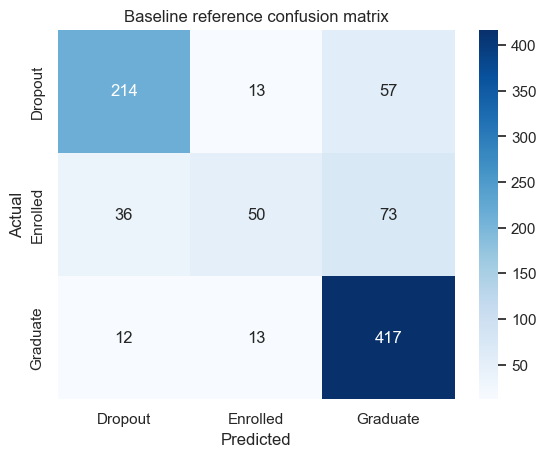

Accuracy           0.7695
Macro Precision    0.7457
Macro Recall       0.6705
Macro-F1           0.6842
Weighted F1        0.7492
Dropout F1         0.7839
Enrolled F1        0.4255
Graduate F1        0.8433
dtype: float64

In [11]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), numerical_cols),
        ("num", "passthrough", categorical_cols),
    ]
)
baseline_pipeline = Pipeline(
    [
        ("preprocessor", baseline_preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
    ]
)
baseline_pipeline.fit(X_train, y_train)
baseline_test_pred = baseline_pipeline.predict(X_test)
baseline_test_metrics = evaluate_predictions(
    y_test, baseline_test_pred, "Baseline", "RandomForest (reference)", split="test"
)
show_evaluation(y_test, baseline_test_pred, "Baseline reference confusion matrix")
display(
    pd.Series(
        {k: v for k, v in baseline_test_metrics.items() if isinstance(v, (int, float))}
    ).round(4)
)

## 11. Controlled experiments

Each experiment changes one main factor and uses the same validation split.

In [12]:
# Feature engineering helpers
# These deterministic features use only predictor columns and are created before model fitting.
def add_engineered_features(data):
    result = data.copy()
    result["1st_sem_approval_rate"] = result[
        "Curricular units 1st sem (approved)"
    ] / result["Curricular units 1st sem (evaluations)"].replace(0, np.nan)
    result["2nd_sem_approval_rate"] = result[
        "Curricular units 2nd sem (approved)"
    ] / result["Curricular units 2nd sem (evaluations)"].replace(0, np.nan)
    result["approval_rate_change"] = (
        result["2nd_sem_approval_rate"] - result["1st_sem_approval_rate"]
    )
    result["approved_units_change"] = (
        result["Curricular units 2nd sem (approved)"]
        - result["Curricular units 1st sem (approved)"]
    )
    result["grade_change"] = (
        result["Curricular units 2nd sem (grade)"]
        - result["Curricular units 1st sem (grade)"]
    )
    result["total_approved_units"] = (
        result["Curricular units 1st sem (approved)"]
        + result["Curricular units 2nd sem (approved)"]
    )
    result["total_without_evaluation"] = (
        result["Curricular units 1st sem (without evaluations)"]
        + result["Curricular units 2nd sem (without evaluations)"]
    )
    return result.replace([np.inf, -np.inf], np.nan).fillna(0)


engineered_num_cols = numerical_cols + [
    "1st_sem_approval_rate",
    "2nd_sem_approval_rate",
    "approval_rate_change",
    "approved_units_change",
    "grade_change",
    "total_approved_units",
    "total_without_evaluation",
]


def make_preprocessor(selected_num_cols):
    return ColumnTransformer(
        [
            ("num", "passthrough", selected_num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ]
    )

## 11. Feature selection

Feature selection is decided on the validation split only. We use model-based importance from a Random Forest fitted on sub-training data, then retain the top numeric features. The test set is not involved.

In [13]:
# Select numeric features using sub-training importance only
selection_preprocessor = ColumnTransformer(
    [
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)
selection_pipeline = Pipeline(
    [
        ("preprocessor", selection_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)
selection_pipeline.fit(X_subtrain, y_subtrain)
feature_names = selection_pipeline.named_steps["preprocessor"].get_feature_names_out()
selection_importance = pd.Series(
    selection_pipeline.named_steps["model"].feature_importances_, index=feature_names
)
numeric_importance = selection_importance[
    selection_importance.index.str.startswith("num__")
].sort_values(ascending=False)
display(numeric_importance.to_frame("importance"))
selected_num_cols = (
    numeric_importance.head(12).index.str.replace("num__", "", regex=False).tolist()
)
print(f"Selected {len(selected_num_cols)} numeric features:", selected_num_cols)

,importance
num__Curricular units 2nd sem (approved),0.112097
num__Curricular units 2nd sem (grade),0.090273
num__Curricular units 1st sem (approved),0.075491
num__Curricular units 1st sem (grade),0.057984
num__Curricular units 2nd sem (evaluations),0.037053
num__Curricular units 1st sem (evaluations),0.035936
num__Age at enrollment,0.033151
num__Unemployment rate,0.022238
num__GDP,0.021694
num__Inflation rate,0.020774


Selected 12 numeric features: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (evaluations)', 'Age at enrollment', 'Unemployment rate', 'GDP', 'Inflation rate', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (enrolled)']


## 12. Feature engineering experiment

The engineered variables summarize semester-to-semester progress and approval rates. They target the overlap around Enrolled without using the target or test set.

In [14]:
# Compare feature selection and feature engineering on the same validation split
selected_preprocessor = make_preprocessor(selected_num_cols)
selected_model = Pipeline(
    [
        ("preprocessor", selected_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)
selected_model.fit(X_subtrain, y_subtrain)
selected_pred = selected_model.predict(X_valid)
experiments.append(
    {
        **evaluate_predictions(
            y_valid, selected_pred, "Exp 06", "RandomForest + feature selection"
        ),
        "Change": "top 12 numeric features",
        "Reason": "Remove lower-importance numeric noise based on sub-training only",
        "Pipeline": selected_model,
    }
)

X_subtrain_engineered = add_engineered_features(X_subtrain)
X_valid_engineered = add_engineered_features(X_valid)
engineered_preprocessor = make_preprocessor(engineered_num_cols)
engineered_model = Pipeline(
    [
        ("preprocessor", engineered_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)
engineered_model.fit(X_subtrain_engineered, y_subtrain)
engineered_pred = engineered_model.predict(X_valid_engineered)
experiments.append(
    {
        **evaluate_predictions(
            y_valid, engineered_pred, "Exp 07", "RandomForest + feature engineering"
        ),
        "Change": "semester progress and approval-rate features",
        "Reason": "Represent academic progression relevant to Enrolled",
        "Pipeline": engineered_model,
    }
)

## 13. Tune Random Forest

Tune only Random Forest configurations using the validation split. The primary objective is Macro-F1, with Enrolled F1 and Accuracy as tie-breakers.

In [15]:
# Controlled Random Forest tuning on engineered features
rf_tuning_candidates = [
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None,
    },
    {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None,
    },
    {
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": None,
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": 0.7,
        "class_weight": None,
    },
    {
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": "balanced",
    },
]
rf_tuning_results = []
for candidate_id, params in enumerate(rf_tuning_candidates, start=1):
    candidate_model = Pipeline(
        [
            ("preprocessor", make_preprocessor(engineered_num_cols)),
            (
                "model",
                RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params),
            ),
        ]
    )
    candidate_model.fit(X_subtrain_engineered, y_subtrain)
    candidate_pred = candidate_model.predict(X_valid_engineered)
    result = evaluate_predictions(
        y_valid, candidate_pred, f"Exp 08.{candidate_id}", "Tuned RandomForest"
    )
    result.update(
        {
            "Change": "Random Forest hyperparameters",
            "Parameters": params,
            "Pipeline": candidate_model,
        }
    )
    rf_tuning_results.append(result)
    experiments.append(result)

rf_tuning_table = pd.DataFrame(
    [
        {k: v for k, v in result.items() if k not in {"Pipeline", "Parameters"}}
        for result in rf_tuning_results
    ]
)
display(
    rf_tuning_table.sort_values(
        ["Macro-F1", "Enrolled F1", "Accuracy"], ascending=False
    ).round(4)
)

,Experiment,Model,Split,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted F1,Dropout F1,Enrolled F1,Graduate F1,Change
3,Exp 08.4,Tuned RandomForest,validation,0.7782,0.7255,0.7008,0.7095,0.7700,0.8018,0.4690,0.8575,Random Forest hyperparameters
0,Exp 08.1,Tuned RandomForest,validation,0.7754,0.7241,0.6897,0.6978,0.7619,0.7939,0.4444,0.8552,Random Forest hyperparameters
4,Exp 08.5,Tuned RandomForest,validation,0.7556,0.7004,0.6953,0.6976,0.7533,0.7726,0.4816,0.8384,Random Forest hyperparameters
1,Exp 08.2,Tuned RandomForest,validation,0.7627,0.7011,0.6763,0.6822,0.7499,0.7824,0.4151,0.8491,Random Forest hyperparameters
2,Exp 08.3,Tuned RandomForest,validation,0.7585,0.6929,0.6655,0.6687,0.7415,0.7828,0.3781,0.8453,Random Forest hyperparameters


## 14. Cross-validated feature selection and feature engineering

The earlier single-validation experiments are retained for context. This section uses 3-fold stratified cross-validation on the training portion only. Candidate representations are compared before Random Forest tuning.

In [16]:
# CV candidates: all features, selected subsets, and domain-motivated engineered features
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "accuracy": "accuracy",
    "macro_f1": make_scorer(f1_score, average="macro"),
    "enrolled_f1": make_scorer(f1_score, labels=[1], average="macro"),
}

feature_subsets = {
    "All features": numerical_cols,
    "Top 12 numeric": selected_num_cols,
    "Top 8 numeric": selected_num_cols[:8],
}
cv_candidates = []
for subset_name, numeric_subset in feature_subsets.items():
    candidate_pipeline = Pipeline(
        [
            ("preprocessor", make_preprocessor(numeric_subset)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    scores = cross_validate(
        candidate_pipeline,
        X_subtrain,
        y_subtrain,
        cv=cv_splitter,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    fitted_candidate = Pipeline(
        [
            ("preprocessor", make_preprocessor(numeric_subset)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    fitted_candidate.fit(X_subtrain, y_subtrain)
    cv_candidates.append(
        {
            "Experiment": f"CV-FS-{subset_name}",
            "Feature Selection": subset_name,
            "Feature Engineering": "No",
            "Model": "RandomForest",
            "Accuracy": scores["test_accuracy"].mean(),
            "Accuracy Std": scores["test_accuracy"].std(),
            "Macro-F1": scores["test_macro_f1"].mean(),
            "Macro-F1 Std": scores["test_macro_f1"].std(),
            "Enrolled F1": scores["test_enrolled_f1"].mean(),
            "Pipeline": fitted_candidate,
            "X_data": X_subtrain,
            "X_full": X_train,
            "representation": subset_name,
        }
    )

X_subtrain_engineered = add_engineered_features(X_subtrain)
X_train_engineered = add_engineered_features(X_train)
for feature_group, numeric_subset in {
    "All engineered": engineered_num_cols,
    "Engineered top 12": selected_num_cols
    + [c for c in engineered_num_cols if c not in numerical_cols],
}.items():
    candidate_pipeline = Pipeline(
        [
            ("preprocessor", make_preprocessor(numeric_subset)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    scores = cross_validate(
        candidate_pipeline,
        X_subtrain_engineered,
        y_subtrain,
        cv=cv_splitter,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    fitted_candidate = Pipeline(
        [
            ("preprocessor", make_preprocessor(numeric_subset)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
                ),
            ),
        ]
    )
    fitted_candidate.fit(X_subtrain_engineered, y_subtrain)
    cv_candidates.append(
        {
            "Experiment": f"CV-FE-{feature_group}",
            "Feature Selection": (
                "Top 12 numeric"
                if feature_group == "Engineered top 12"
                else "All features"
            ),
            "Feature Engineering": feature_group,
            "Model": "RandomForest",
            "Accuracy": scores["test_accuracy"].mean(),
            "Accuracy Std": scores["test_accuracy"].std(),
            "Macro-F1": scores["test_macro_f1"].mean(),
            "Macro-F1 Std": scores["test_macro_f1"].std(),
            "Enrolled F1": scores["test_enrolled_f1"].mean(),
            "Pipeline": fitted_candidate,
            "X_data": X_subtrain_engineered,
            "X_full": X_train_engineered,
            "representation": feature_group,
        }
    )

cv_representation_table = pd.DataFrame(
    [
        {k: v for k, v in row.items() if k not in {"Pipeline", "X_data", "X_full"}}
        for row in cv_candidates
    ]
).sort_values(["Macro-F1", "Enrolled F1", "Accuracy"], ascending=False)
display(cv_representation_table.round(4))

,Experiment,Feature Selection,Feature Engineering,Model,Accuracy,Accuracy Std,Macro-F1,Macro-F1 Std,Enrolled F1,representation
3,CV-FE-All engineered,All features,All engineered,RandomForest,0.7676,0.0157,0.6808,0.0142,0.4086,All engineered
4,CV-FE-Engineered top 12,Top 12 numeric,Engineered top 12,RandomForest,0.7651,0.0170,0.6793,0.0147,0.4114,Engineered top 12
0,CV-FS-All features,All features,No,RandomForest,0.7672,0.0198,0.6726,0.0163,0.3862,All features
1,CV-FS-Top 12 numeric,Top 12 numeric,No,RandomForest,0.7658,0.0209,0.6711,0.0203,0.3802,Top 12 numeric
2,CV-FS-Top 8 numeric,Top 8 numeric,No,RandomForest,0.7573,0.0178,0.6569,0.0188,0.3496,Top 8 numeric


## 15. RandomizedSearchCV for Random Forest

Only the best cross-validated representation is tuned. The search uses training folds only and optimizes `f1_macro`; custom class weights are included to test whether Enrolled benefits without changing validation/test distributions.

In [17]:
# Tune only the strongest CV representation
cv_best_row = cv_representation_table.iloc[0]
best_representation = cv_best_row["representation"]
best_cv_candidate = next(
    row for row in cv_candidates if row["representation"] == best_representation
)
best_cv_X = best_cv_candidate["X_data"]
best_cv_X_full = best_cv_candidate["X_full"]
best_cv_numeric_cols = (
    engineered_num_cols
    if best_representation == "All engineered"
    else (
        selected_num_cols + [c for c in engineered_num_cols if c not in numerical_cols]
        if best_representation == "Engineered top 12"
        else (
            numerical_cols
            if best_representation == "All features"
            else (
                selected_num_cols[:8]
                if best_representation == "Top 8 numeric"
                else selected_num_cols
            )
        )
    )
)
rf_search_pipeline = Pipeline(
    [
        ("preprocessor", make_preprocessor(best_cv_numeric_cols)),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)
rf_param_distributions = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 12, 16, 20, 28],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [
        None,
        "balanced",
        {0: 1.0, 1: 1.25, 2: 1.0},
        {0: 1.0, 1: 1.5, 2: 1.0},
    ],
}
rf_search = RandomizedSearchCV(
    rf_search_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=10,
    scoring="f1_macro",
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)
rf_search.fit(best_cv_X, y_subtrain)
print("Best representation:", best_representation)
print("Best RF parameters:", rf_search.best_params_)
print(f"Best RF CV Macro-F1: {rf_search.best_score_:.4f}")

Best representation: All engineered
Best RF parameters: {'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__criterion': 'entropy', 'model__class_weight': 'balanced'}
Best RF CV Macro-F1: 0.7044


## 16. Enrolled error analysis and CV model selection

The confusion matrix below is diagnostic on the validation split only. It does not alter the data distribution or select hyperparameters. Selection remains based on cross-validated Macro-F1, then Enrolled F1 and Accuracy.

,Experiment,Feature Selection,Feature Engineering,Model,Accuracy,Accuracy Std,Macro-F1,Macro-F1 Std,Enrolled F1,representation
5,RF-RandomizedSearchCV,All features,All engineered,RandomForest tuned,0.7679,0.0200,0.7044,0.0221,0.4844,All engineered
3,CV-FE-All engineered,All features,All engineered,RandomForest,0.7676,0.0157,0.6808,0.0142,0.4086,All engineered
4,CV-FE-Engineered top 12,Top 12 numeric,Engineered top 12,RandomForest,0.7651,0.0170,0.6793,0.0147,0.4114,Engineered top 12
0,CV-FS-All features,All features,No,RandomForest,0.7672,0.0198,0.6726,0.0163,0.3862,All features
1,CV-FS-Top 12 numeric,Top 12 numeric,No,RandomForest,0.7658,0.0209,0.6711,0.0203,0.3802,Top 12 numeric
2,CV-FS-Top 8 numeric,Top 8 numeric,No,RandomForest,0.7573,0.0178,0.6569,0.0188,0.3496,Top 8 numeric


Validation-only diagnostic for the CV-selected model:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       227
    Enrolled       0.50      0.43      0.47       127
    Graduate       0.82      0.90      0.85       354

    accuracy                           0.77       708
   macro avg       0.71      0.69      0.70       708
weighted avg       0.76      0.77      0.76       708



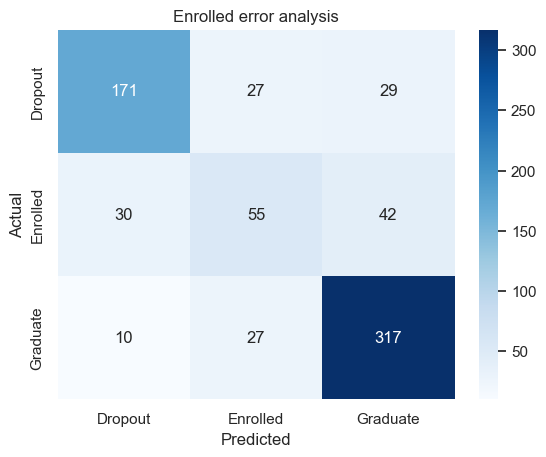

Enrolled predicted as Dropout: 30
Enrolled predicted as Graduate: 42


In [18]:
# Score the tuned estimator with the same CV metrics and build the final CV ranking
rf_cv_scores = cross_validate(
    rf_search.best_estimator_,
    best_cv_X,
    y_subtrain,
    cv=cv_splitter,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False,
)
rf_cv_row = {
    "Experiment": "RF-RandomizedSearchCV",
    "Feature Selection": cv_best_row["Feature Selection"],
    "Feature Engineering": cv_best_row["Feature Engineering"],
    "Model": "RandomForest tuned",
    "Accuracy": rf_cv_scores["test_accuracy"].mean(),
    "Accuracy Std": rf_cv_scores["test_accuracy"].std(),
    "Macro-F1": rf_cv_scores["test_macro_f1"].mean(),
    "Macro-F1 Std": rf_cv_scores["test_macro_f1"].std(),
    "Enrolled F1": rf_cv_scores["test_enrolled_f1"].mean(),
    "Pipeline": rf_search.best_estimator_,
    "X_data": best_cv_X,
    "X_full": best_cv_X_full,
    "representation": best_representation,
}
cv_selection_rows = cv_candidates + [rf_cv_row]
cv_selection_table = pd.DataFrame(
    [
        {k: v for k, v in row.items() if k not in {"Pipeline", "X_data", "X_full"}}
        for row in cv_selection_rows
    ]
).sort_values(["Macro-F1", "Enrolled F1", "Accuracy"], ascending=False)
display(cv_selection_table.round(4))

best_cv_row = cv_selection_table.iloc[0]
best_cv_result = next(
    row
    for row in cv_selection_rows
    if row["Experiment"] == best_cv_row["Experiment"]
    and row["representation"] == best_cv_row["representation"]
)
best_representation = best_cv_result["representation"]
best_cv_numeric_cols = (
    engineered_num_cols
    if best_representation == "All engineered"
    else (
        selected_num_cols + [c for c in engineered_num_cols if c not in numerical_cols]
        if best_representation == "Engineered top 12"
        else (
            numerical_cols
            if best_representation == "All features"
            else (
                selected_num_cols[:8]
                if best_representation == "Top 8 numeric"
                else selected_num_cols
            )
        )
    )
)
best_cv_X_full = (
    X_train_engineered
    if best_representation in {"All engineered", "Engineered top 12"}
    else X_train
)
best_model_template = best_cv_result["Pipeline"]
validation_X_for_best = (
    X_valid_engineered
    if best_representation in {"All engineered", "Engineered top 12"}
    else X_valid
)
validation_pred = best_model_template.predict(validation_X_for_best)
validation_report = evaluate_predictions(
    y_valid, validation_pred, best_cv_row["Experiment"], best_cv_row["Model"]
)
print("Validation-only diagnostic for the CV-selected model:")
show_evaluation(y_valid, validation_pred, "Enrolled error analysis")
cm = confusion_matrix(y_valid, validation_pred)
print(f"Enrolled predicted as Dropout: {cm[1, 0]}")
print(f"Enrolled predicted as Graduate: {cm[1, 2]}")

## 17. Class imbalance experiments

The class distribution and validation confusion matrix are inspected before balancing. All balancing is applied only inside training folds. Validation and test distributions remain natural.

In [19]:
# Imbalance overview and Current Best diagnostic on validation only
class_balance = pd.DataFrame(
    {
        "count": pd.Series(y_train).value_counts().sort_index(),
        "percentage": pd.Series(y_train).value_counts(normalize=True).sort_index()
        * 100,
    },
    index=CLASS_NAMES,
)
display(class_balance.round(2))
print("Current Best validation metrics:")
print(
    classification_report(
        y_valid, validation_pred, target_names=CLASS_NAMES, zero_division=0
    )
)
current_best_cm = confusion_matrix(y_valid, validation_pred)
display(pd.DataFrame(current_best_cm, index=CLASS_NAMES, columns=CLASS_NAMES))
print(f"Enrolled -> Dropout: {current_best_cm[1, 0]}")
print(f"Enrolled -> Graduate: {current_best_cm[1, 2]}")

,count,percentage
Dropout,NaN,NaN
Enrolled,NaN,NaN
Graduate,NaN,NaN


Current Best validation metrics:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       227
    Enrolled       0.50      0.43      0.47       127
    Graduate       0.82      0.90      0.85       354

    accuracy                           0.77       708
   macro avg       0.71      0.69      0.70       708
weighted avg       0.76      0.77      0.76       708



,Dropout,Enrolled,Graduate
Dropout,171,27,29
Enrolled,30,55,42
Graduate,10,27,317


Enrolled -> Dropout: 30
Enrolled -> Graduate: 42


## 18. Class weight and RandomOverSampler comparison

The tuned Random Forest hyperparameters are held fixed while balancing changes one factor at a time. Model selection uses 3-fold CV Macro-F1, then validation Enrolled F1 and Accuracy as diagnostic tie-breakers.

In [20]:
# Controlled imbalance candidates on the CV-selected feature representation
base_rf_params = rf_search.best_estimator_.named_steps["model"].get_params()
base_rf_params = {
    key: value
    for key, value in base_rf_params.items()
    if key not in {"random_state", "n_jobs", "class_weight"}
}
weight_candidates = {
    "A Current Best / no weighting": None,
    "B balanced": "balanced",
    "C Enrolled 1.25x": {0: 1.0, 1: 1.25, 2: 1.0},
    "D Enrolled 1.50x": {0: 1.0, 1: 1.50, 2: 1.0},
    "E Enrolled 1.75x": {0: 1.0, 1: 1.75, 2: 1.0},
}
imbalance_rows = []
imbalance_models = {}
for experiment_name, class_weight in weight_candidates.items():
    model = Pipeline(
        [
            ("preprocessor", make_preprocessor(best_cv_numeric_cols)),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    class_weight=class_weight,
                    **base_rf_params,
                ),
            ),
        ]
    )
    cv_scores = cross_validate(
        model,
        best_cv_X,
        y_subtrain,
        cv=cv_splitter,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    model.fit(best_cv_X, y_subtrain)
    validation_input = (
        X_valid_engineered
        if best_representation in {"All engineered", "Engineered top 12"}
        else X_valid
    )
    validation_prediction = model.predict(validation_input)
    validation_metrics = evaluate_predictions(
        y_valid, validation_prediction, experiment_name, "RandomForest"
    )
    imbalance_rows.append(
        {
            "Experiment": experiment_name,
            "Balancing": "None" if class_weight is None else str(class_weight),
            "Accuracy": cv_scores["test_accuracy"].mean(),
            "Macro-F1": cv_scores["test_macro_f1"].mean(),
            "Enrolled F1": cv_scores["test_enrolled_f1"].mean(),
            "Dropout F1": validation_metrics["Dropout F1"],
            "Graduate F1": validation_metrics["Graduate F1"],
            "Validation Accuracy": validation_metrics["Accuracy"],
            "Validation Macro-F1": validation_metrics["Macro-F1"],
            "Validation Enrolled F1": validation_metrics["Enrolled F1"],
        }
    )
    imbalance_models[experiment_name] = model

# Oversampling happens after preprocessing and only inside each training fold.
ros_model = ImbPipeline(
    [
        ("preprocessor", make_preprocessor(best_cv_numeric_cols)),
        ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE, n_jobs=-1, **base_rf_params
            ),
        ),
    ]
)
ros_scores = cross_validate(
    ros_model,
    best_cv_X,
    y_subtrain,
    cv=cv_splitter,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False,
)
ros_model.fit(best_cv_X, y_subtrain)
ros_validation_prediction = ros_model.predict(validation_input)
ros_validation_metrics = evaluate_predictions(
    y_valid, ros_validation_prediction, "F RandomOverSampler", "RandomForest"
)
imbalance_rows.append(
    {
        "Experiment": "F RandomOverSampler",
        "Balancing": "RandomOverSampler on training folds",
        "Accuracy": ros_scores["test_accuracy"].mean(),
        "Macro-F1": ros_scores["test_macro_f1"].mean(),
        "Enrolled F1": ros_scores["test_enrolled_f1"].mean(),
        "Dropout F1": ros_validation_metrics["Dropout F1"],
        "Graduate F1": ros_validation_metrics["Graduate F1"],
        "Validation Accuracy": ros_validation_metrics["Accuracy"],
        "Validation Macro-F1": ros_validation_metrics["Macro-F1"],
        "Validation Enrolled F1": ros_validation_metrics["Enrolled F1"],
    }
)
imbalance_models["F RandomOverSampler"] = ros_model
imbalance_table = (
    pd.DataFrame(imbalance_rows)
    .sort_values(["Macro-F1", "Enrolled F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
display(imbalance_table.round(4))

,Experiment,Balancing,Accuracy,Macro-F1,Enrolled F1,Dropout F1,Graduate F1,Validation Accuracy,Validation Macro-F1,Validation Enrolled F1
0,F RandomOverSampler,RandomOverSampler on training folds,0.7598,0.7048,0.4969,0.7880,0.8493,0.7627,0.7019,0.4683
1,B balanced,balanced,0.7679,0.7044,0.4844,0.7808,0.8544,0.7669,0.7005,0.4661
2,E Enrolled 1.75x,"{0: 1.0, 1: 1.75, 2: 1.0}",0.7662,0.6991,0.4754,0.7870,0.8655,0.7782,0.7111,0.4807
3,D Enrolled 1.50x,"{0: 1.0, 1: 1.5, 2: 1.0}",0.7647,0.6952,0.4636,0.7844,0.8598,0.7712,0.7010,0.4589
4,A Current Best / no weighting,None,0.7672,0.6941,0.4563,0.7918,0.8575,0.7740,0.7047,0.4649
5,C Enrolled 1.25x,"{0: 1.0, 1: 1.25, 2: 1.0}",0.7651,0.6939,0.4587,0.7808,0.8594,0.7684,0.6968,0.4502


## 19. Select imbalance strategy

SMOTENC is not forced here: the dataset stores categorical variables as numeric codes, while the selected representation already uses one-hot encoding. RandomOverSampler is the safer controlled oversampling comparison. A candidate is rejected if its validation Dropout or Graduate F1 falls materially below Current Best.

In [21]:
# Select with CV Macro-F1 priority and a guard against severe class regressions
current_best_validation = validation_report
class_floor = {
    "Dropout F1": current_best_validation["Dropout F1"] - 0.03,
    "Graduate F1": current_best_validation["Graduate F1"] - 0.03,
}
eligible_imbalance = imbalance_table[
    (imbalance_table["Dropout F1"] >= class_floor["Dropout F1"])
    & (imbalance_table["Graduate F1"] >= class_floor["Graduate F1"])
].copy()
if eligible_imbalance.empty:
    selected_imbalance_name = "A Current Best / no weighting"
else:
    selected_imbalance_name = eligible_imbalance.iloc[0]["Experiment"]
selected_imbalance_model = imbalance_models[selected_imbalance_name]
selected_imbalance_row = imbalance_table[
    imbalance_table["Experiment"] == selected_imbalance_name
].iloc[0]
print("Selected imbalance strategy:", selected_imbalance_name)
print("Selection uses CV Macro-F1, Enrolled F1, Accuracy, with class-regression guard.")
print(
    "Current Best validation:",
    current_best_validation["Macro-F1"],
    current_best_validation["Enrolled F1"],
)
print(
    "Selected CV:",
    selected_imbalance_row["Macro-F1"],
    selected_imbalance_row["Enrolled F1"],
)

Selected imbalance strategy: F RandomOverSampler
Selection uses CV Macro-F1, Enrolled F1, Accuracy, with class-regression guard.
Current Best validation: 0.7004570173588577 0.4661016949152542
Selected CV: 0.7048101092355067 0.49687142210506696


## 12. Experiment comparison

We retain weaker experiments and rank validation results by Macro-F1, Enrolled F1, then Accuracy.

,Experiment,Model,Split,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted F1,Dropout F1,Enrolled F1,Graduate F1,Change,Reason,Parameters
0,Baseline,RandomForest (reference),test,0.7695,0.7457,0.6705,0.6842,0.7492,0.7839,0.4255,0.8433,NaN,NaN,NaN
6,Exp 08.4,Tuned RandomForest,validation,0.7782,0.7255,0.7008,0.7095,0.7700,0.8018,0.4690,0.8575,Random Forest hyperparameters,NaN,"{'n_estimators': 500, 'max_depth': None, 'min_..."
2,Exp 07,RandomForest + feature engineering,validation,0.7754,0.7241,0.6897,0.6978,0.7619,0.7939,0.4444,0.8552,semester progress and approval-rate features,Represent academic progression relevant to Enr...,NaN
3,Exp 08.1,Tuned RandomForest,validation,0.7754,0.7241,0.6897,0.6978,0.7619,0.7939,0.4444,0.8552,Random Forest hyperparameters,NaN,"{'n_estimators': 300, 'max_depth': None, 'min_..."
1,Exp 06,RandomForest + feature selection,validation,0.7825,0.7340,0.6894,0.6977,0.7655,0.7904,0.4343,0.8684,top 12 numeric features,Remove lower-importance numeric noise based on...,NaN
7,Exp 08.5,Tuned RandomForest,validation,0.7556,0.7004,0.6953,0.6976,0.7533,0.7726,0.4816,0.8384,Random Forest hyperparameters,NaN,"{'n_estimators': 500, 'max_depth': 20, 'min_sa..."
4,Exp 08.2,Tuned RandomForest,validation,0.7627,0.7011,0.6763,0.6822,0.7499,0.7824,0.4151,0.8491,Random Forest hyperparameters,NaN,"{'n_estimators': 500, 'max_depth': 16, 'min_sa..."
5,Exp 08.3,Tuned RandomForest,validation,0.7585,0.6929,0.6655,0.6687,0.7415,0.7828,0.3781,0.8453,Random Forest hyperparameters,NaN,"{'n_estimators': 500, 'max_depth': 20, 'min_sa..."


,Experiment,Model,Accuracy,Macro-F1,Dropout F1,Enrolled F1,Graduate F1
0,Exp 08.4,Tuned RandomForest,0.7782,0.7095,0.8018,0.4690,0.8575
1,Exp 07,RandomForest + feature engineering,0.7754,0.6978,0.7939,0.4444,0.8552
2,Exp 08.1,Tuned RandomForest,0.7754,0.6978,0.7939,0.4444,0.8552
3,Exp 06,RandomForest + feature selection,0.7825,0.6977,0.7904,0.4343,0.8684
4,Exp 08.5,Tuned RandomForest,0.7556,0.6976,0.7726,0.4816,0.8384
5,Exp 08.2,Tuned RandomForest,0.7627,0.6822,0.7824,0.4151,0.8491
6,Exp 08.3,Tuned RandomForest,0.7585,0.6687,0.7828,0.3781,0.8453


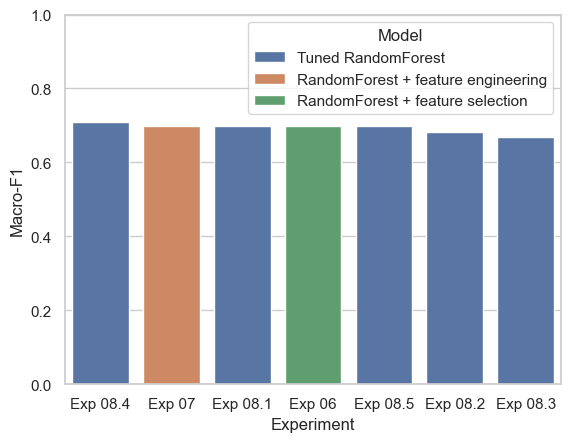

In [22]:
experiment_table = pd.DataFrame(
    [
        baseline_test_metrics,
        *[
            {k: v for k, v in result.items() if k != "Pipeline"}
            for result in experiments
        ],
    ]
)
display(
    experiment_table.sort_values(["Split", "Macro-F1"], ascending=[True, False]).round(
        4
    )
)
validation_table = (
    experiment_table[experiment_table["Split"] == "validation"]
    .sort_values(["Macro-F1", "Enrolled F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
display(
    validation_table[
        [
            "Experiment",
            "Model",
            "Accuracy",
            "Macro-F1",
            "Dropout F1",
            "Enrolled F1",
            "Graduate F1",
        ]
    ].round(4)
)
sns.barplot(
    data=validation_table, x="Experiment", y="Macro-F1", hue="Model", dodge=False
)
plt.ylim(0, 1)
plt.show()

## 13. Feature importance

Importance is inspected after validation selection and is descriptive only.

In [23]:
# Feature importance for the CV-selected model
model_step = best_model_template.named_steps["model"]
feature_names = best_model_template.named_steps["preprocessor"].get_feature_names_out()
if hasattr(model_step, "feature_importances_"):
    importance = pd.Series(
        model_step.feature_importances_, index=feature_names
    ).sort_values(ascending=False)
    display(importance.head(20).to_frame("importance"))
else:
    permutation = permutation_importance(
        best_model_template,
        validation_X_for_best,
        y_valid,
        scoring="f1_macro",
        n_repeats=5,
        random_state=RANDOM_STATE,
    )
    display(
        pd.Series(permutation.importances_mean, index=validation_X_for_best.columns)
        .sort_values(ascending=False)
        .head(20)
    )

,importance
num__2nd_sem_approval_rate,0.162391
num__Curricular units 2nd sem (approved),0.076451
num__total_approved_units,0.060176
num__Curricular units 2nd sem (grade),0.053741
num__1st_sem_approval_rate,0.052234
num__Age at enrollment,0.037389
num__Curricular units 1st sem (grade),0.036693
num__grade_change,0.031752
num__approval_rate_change,0.029772
num__GDP,0.026883


## 14. Final evaluation

Refit the validation-selected configuration on all training data, then evaluate the held-out test set once.

              precision    recall  f1-score   support

     Dropout       0.85      0.71      0.77       284
    Enrolled       0.49      0.54      0.51       159
    Graduate       0.83      0.88      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



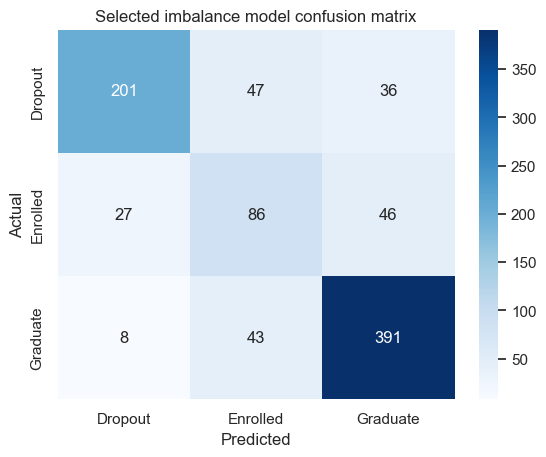

,Experiment,Model,Accuracy,Macro-F1,Dropout F1,Enrolled F1,Graduate F1
0,Baseline,RandomForest (reference),0.7695,0.6842,0.7839,0.4255,0.8433
1,F RandomOverSampler final,RandomForest with imbalance strategy,0.7661,0.7137,0.7731,0.5134,0.8546


In [24]:
# Final evaluation: fit the selected imbalance strategy on all training data once
best_model = selected_imbalance_model
best_model.fit(best_cv_X_full, y_train)
fit_test = (
    add_engineered_features(X_test)
    if best_representation in {"All engineered", "Engineered top 12"}
    else X_test
)
best_test_pred = best_model.predict(fit_test)
best_test_metrics = evaluate_predictions(
    y_test,
    best_test_pred,
    f"{selected_imbalance_name} final",
    "RandomForest with imbalance strategy",
    split="test",
)
show_evaluation(y_test, best_test_pred, "Selected imbalance model confusion matrix")
display(
    pd.DataFrame([baseline_test_metrics, best_test_metrics])[
        [
            "Experiment",
            "Model",
            "Accuracy",
            "Macro-F1",
            "Dropout F1",
            "Enrolled F1",
            "Graduate F1",
        ]
    ].round(4)
)

## 15. Save model and final report

The complete fitted pipeline stores preprocessing and model together.

In [25]:
# Save the selected imbalance model and final metrics
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.joblib")
final_report = pd.DataFrame(
    {
        "Baseline": [
            baseline_test_metrics["Accuracy"],
            baseline_test_metrics["Macro-F1"],
            baseline_test_metrics["Enrolled F1"],
        ],
        "Best optimized": [
            best_test_metrics["Accuracy"],
            best_test_metrics["Macro-F1"],
            best_test_metrics["Enrolled F1"],
        ],
    },
    index=["Accuracy", "Macro-F1", "Enrolled F1"],
)
final_report["Improvement"] = final_report["Best optimized"] - final_report["Baseline"]
display((final_report * 100).round(2).astype(str) + "%")
metrics_to_save = {
    "baseline_test": baseline_test_metrics,
    "best_test": best_test_metrics,
    "selected_experiment": selected_imbalance_name,
    "selected_representation": best_representation,
    "imbalance_cv_table": imbalance_table.to_dict(orient="records"),
    "random_state": RANDOM_STATE,
    "target_classes": CLASS_NAMES,
}
with open("models/metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics_to_save, file, indent=2, default=float)
print(
    f"Selected {selected_imbalance_name} using CV Macro-F1, Enrolled F1, then Accuracy."
)
print("The test set was untouched during balancing selection.")

,Baseline,Best optimized,Improvement
Accuracy,76.95%,76.61%,-0.34%
Macro-F1,68.42%,71.37%,2.95%
Enrolled F1,42.55%,51.34%,8.79%


Selected F RandomOverSampler using CV Macro-F1, Enrolled F1, then Accuracy.
The test set was untouched during balancing selection.
